In [1]:
import numpy as np
import pandas as pd
import os, sys, re, math, h5py
from pyLIMA.outputs import pyLIMA_plots
sys.path.append(os.path.dirname(os.getcwd()))
from functions_roman_rubin import read_data, model_rubin_roman
from bokeh.plotting import figure, show, output_file
from bokeh.layouts import gridplot, row, column
from bokeh.io import export_png
# from plot_saveLC import plot_n_save
import os
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import corner
import seaborn as sns
import matplotlib.lines as mlines
from functions_roman_rubin import fit_rubin_roman

/home/anibal-pc/microlensing/simulation_Rubin/roman_rubin


In [2]:
from paramiko import SSHClient, AutoAddPolicy
from scp import SCPClient
ssh = SSHClient()
ssh.set_missing_host_key_policy(AutoAddPolicy())
ssh.connect(
    hostname='152.84.248.250', 
    port=13900,  # <-- tu puerto personalizado
    username='anibalvarela', 
    password='38victorioso177'
)

In [2]:
source = 0
nset = 1

# BH  FFP  Planets_systems
path_true =f'/share/storage3/rubin/microlensing/romanrubin/RR2025/April_set/Planets_systems/set_sim{nset}/Event_{source}.h5'
path_rr =f'/share/storage3/rubin/microlensing/romanrubin/RR2025/April_set/Planets_systems/set_fit{nset}/Event_RR_{source}_TRF.npy'
path_roman = f'/share/storage3/rubin/microlensing/romanrubin/RR2025/April_set/Planets_systems/set_fit{nset}/Event_Roman_{source}_TRF.npy'#f'Event_Roman_{i}_TRF.npy'

path_save = '/home/anibal-pc/results_roman_rubin/hit_the_boundaries/USBL/'

os.makedirs(path_save, exist_ok=True)

In [4]:
with SCPClient(ssh.get_transport()) as scp:
    scp.get(path_rr, path_save)
    scp.get(path_roman, path_save)
    scp.get(path_true, path_save)

In [3]:
path_ephemerides = str(os.path.dirname(os.getcwd()))+'/ephemerides/Roman_positions.npy'
path_event = path_save+f'Event_{source}.h5'
path_fit_rr = path_save+f'Event_RR_{source}_TRF.npy'
path_fit_roman = path_save+f'Event_Roman_{source}_TRF.npy'
path_to_save_fit = '/home/anibal-pc/'

In [8]:
import numpy as np
import pandas as pd
import os, sys, re, math, h5py

from pyLIMA.outputs import pyLIMA_plots

sys.path.append(os.path.dirname(os.getcwd()))
from functions_roman_rubin import read_data, model_rubin_roman

from bokeh.plotting import figure, show, output_file, reset_output
from bokeh.layouts import gridplot, row, column
from bokeh.io import export_png
from bokeh.models import ColumnDataSource, DataTable, TableColumn
from bokeh.models import Span

from decimal import Decimal, ROUND_DOWN, InvalidOperation

# from decimal import Decimal, ROUND_DOWN

def round_nfig(numero):
    if numero == 0:
        return 0
    cifras_significativas = 3
    # Calcula el número de decimales necesarios
    exponente = int("{:e}".format(abs(numero)).split("e")[1])
    decimales = max(cifras_significativas - 1 - exponente, 2)  # Asegura al menos 2 decimales
    return round(numero, decimales)
    
# def round_with_matching_decimals(num1, num2):
#     # Convert to Decimal for precision
#     num1, num2 = Decimal(num1), Decimal(num2)

#     # Identify the smaller and larger numbers
#     smaller, larger = (num1, num2) if abs(num1) < abs(num2) else (num2, num1)

#     # Round the smaller number to 3 significant figures
#     rounded_smaller = round(smaller, 3 - smaller.adjusted() - 1)

#     # Determine the number of decimal places in the rounded smaller number
#     decimal_places = abs(Decimal(str(rounded_smaller)).as_tuple().exponent)
#     print('larger',larger)
#     print('decimal_places',decimal_places)
#     # Round the larger number to match the decimal places
#     rounded_larger = larger.quantize(Decimal(f"1E-{decimal_places}"), rounding=ROUND_DOWN)

#     return float(rounded_smaller), float(rounded_larger)


def round_with_matching_decimals(num1, num2, max_decimal_places=10):
    try:
        # Convert to Decimal for precision
        num1, num2 = Decimal(num1), Decimal(num2)

        # Identify the smaller and larger numbers
        smaller, larger = (num1, num2) if abs(num1) < abs(num2) else (num2, num1)

        # Round the smaller number to 3 significant figures
        rounded_smaller = round(smaller, 3 - smaller.adjusted() - 1)

        # Determine the number of decimal places in the rounded smaller number
        decimal_places = abs(Decimal(str(rounded_smaller)).as_tuple().exponent)
        decimal_places = min(decimal_places, max_decimal_places)  # Limitar la precisión

        print('larger', larger)
        print('decimal_places', decimal_places)

        # Round the larger number to match the decimal places
        quant = Decimal(f"1E-{decimal_places}")
        rounded_larger = larger.quantize(quant, rounding=ROUND_DOWN)

        return float(rounded_smaller), float(rounded_larger)

    except (InvalidOperation, ValueError) as e:
        print(f"[ERROR round_with_matching_decimals]: {e}")
        return float(num1), float(num2)

def round_single(x):
    return round(x, -int(np.floor(np.log10(abs(x)))))  # Example function to round to significant figures


def plot_n_save(Source,path_save,path_event, path_fit_rr, path_fit_roman, path_ephemerides, model):
    
    colorbands={'W149':'b', 'u':'purple', 'g':'g', 'r':'red',
          'i':'yellow', 'z':'k', 'y':'cyan'}

    
    ZP = {'W149':27.615, 'u':27.03, 'g':28.38, 'r':28.16,
              'i':27.85, 'z':27.46, 'y':26.68}
    # model_ulens = 'USBL'

    
    info, pyLIMA_parameters, bands = read_data(path_event)
    data_fit_rr = np.load(path_fit_rr,allow_pickle=True).item()
    data_fit_roman = np.load(path_fit_roman,allow_pickle=True).item()
    origin = info[2]
    ulens_params = []

    PAR = ['tE','piEN','piEE']
    if model == 'USBL':
        PAR = ['t_center','u_center','rho','separation','mass_ratio','alpha']+PAR
    elif model=='FSPL':
        PAR = ['t0','u0','rho']+PAR
    elif model =='PSPL':
        PAR = ['t0','u0']+PAR
        
    for b in (PAR):
        ulens_params.append(pyLIMA_parameters[b])
    flux_params = []
    for b in bands:
        if not len(bands[b])==0:
            zp_Rubin_to_pyLIMA = (10**((-27.4+ZP[b])/2.5))
            
            flux_params.append(pyLIMA_parameters['fsource_'+b]/zp_Rubin_to_pyLIMA)
            flux_params.append(pyLIMA_parameters['ftotal_'+b]/zp_Rubin_to_pyLIMA)
            
    true_params = ulens_params+flux_params
    
    
    f= 'W149'
    wfirst_lc = np.array([bands[f]['time'],bands[f]['mag'],bands[f]['err_mag']]).T
    f = 'u'
    lsst_u = np.array([bands[f]['time'],bands[f]['mag'],bands[f]['err_mag']]).T
    f='g'
    lsst_g = np.array([bands[f]['time'],bands[f]['mag'],bands[f]['err_mag']]).T
    f='r'
    lsst_r = np.array([bands[f]['time'],bands[f]['mag'],bands[f]['err_mag']]).T
    f='i'
    lsst_i = np.array([bands[f]['time'],bands[f]['mag'],bands[f]['err_mag']]).T
    f='z'
    lsst_z = np.array([bands[f]['time'],bands[f]['mag'],bands[f]['err_mag']]).T
    f='y'
    lsst_y = np.array([bands[f]['time'],bands[f]['mag'],bands[f]['err_mag']]).T
    

    if model=='USBL':
        t0_str='t_center'
        u0_str='u_center'
    else:
        t0_str='t0'
        u0_str='u0'
        
    model_rr = model_rubin_roman(Source,False,{t0_str:data_fit_rr['best_model'][0]}, path_ephemerides,model,origin, wfirst_lc, lsst_u, lsst_g, lsst_r, lsst_i, lsst_z,
                        lsst_y)
    
    model_roman = model_rubin_roman(Source,False,{t0_str:data_fit_roman['best_model'][0]}, path_ephemerides,model,origin, wfirst_lc, [], [], [], [], [],[])
    
    chi2_roman = data_fit_roman['chi2']
    chi2_rr = data_fit_rr['chi2']
    DOF_roman = len(model_roman.event.telescopes[0].lightcurve['time'])-len(data_fit_roman['best_model'])
    DOF_rr = sum([len(model_rr.event.telescopes[i].lightcurve['time']) for i in range(len(model_rr.event.telescopes))])-len(data_fit_rr['best_model'])
    print('Chi square reduced for Roman', chi2_roman/DOF_roman)
    print('Chi square reduced for RR', chi2_rr/DOF_rr)
    
    # Create a Bokeh figure
    bokeh_plot = figure(
        width=800*2, height=400*2,
        title="Microlensing Photometric Models",
        x_axis_label="Time",
        y_axis_label="Magnitude",
        tools="pan,wheel_zoom,box_zoom,reset"
    )
    
    # Call the function to plot the photometric models
    pyLIMA_plots.plot_photometric_models(
        figure_axe=None,  # Pass None if you're only using Bokeh
        microlensing_model=model_rr,
        model_parameters=data_fit_rr['best_model'],
        bokeh_plot=bokeh_plot,
        plot_unit='Mag'
    )
    # Call the function to plot the photometric models
    pyLIMA_plots.plot_photometric_models(
        figure_axe=None,  # Pass None if you're only using Bokeh
        microlensing_model=model_roman,
        model_parameters=data_fit_roman['best_model'],
        bokeh_plot=bokeh_plot,
        plot_unit='Mag'
    )
    
    pyLIMA_plots.plot_aligned_data(figure_axe=None,  # Pass None if you're only using Bokeh
        microlensing_model=model_rr,
        model_parameters=data_fit_rr['best_model'],
        bokeh_plot=bokeh_plot,
        plot_unit='Mag'
    )
    
    bokeh_plot.renderers[0].glyph.line_color = "blue"
    bokeh_plot.renderers[1].glyph.line_color = "red"
    
    bokeh_plot.y_range.flipped = True
    
    plot_residual_rr = figure(title=f"Residuals Roman+Rubin fit: chi2={chi2_rr/DOF_rr}", width=800*2, height=300)
    pyLIMA_plots.plot_residuals(None, model_rr, data_fit_rr['best_model'],bokeh_plot=plot_residual_rr, plot_unit='Mag')
    
    
    plot_residual_roman = figure(title=f"Residuals Roman fit: chi2={chi2_roman/DOF_roman}", width=800*2, height=300)
    pyLIMA_plots.plot_residuals(None, model_roman, data_fit_roman['best_model'],bokeh_plot=plot_residual_roman, plot_unit='Mag')

    # show(bokeh_plot)

    if True:
    
        
        # Disposición vertical
        layout_vertical = column(bokeh_plot, plot_residual_rr,plot_residual_roman)
        # export_png(layout_vertical, filename="grid_plot.png")
    
    
        # print('p-value of a chi squared test', chi2.sf(chi2_roman, DOF_roman))
        
        #metric alpha
        long = len(data_fit_roman['best_model'])-2
        TRUE = np.array(true_params[0:long])
        F_rr = np.array(data_fit_rr['best_model'][0:long])
        F_roman = np.array(data_fit_roman['best_model'][0:long])
        S_rr =np.array(np.sqrt(np.diag(data_fit_rr['covariance_matrix']))[0:long])
        S_roman =np.array(np.sqrt(np.diag(data_fit_roman['covariance_matrix']))[0:long])
        
        alpha_roman = abs(TRUE-F_roman)/abs(TRUE)
        alpha_rr = abs(TRUE-F_rr)/abs(TRUE)
        #metric beta
        beta_roman = abs(TRUE-F_roman)/abs(S_roman)
        beta_rr = abs(TRUE-F_rr)/abs(S_rr)
        #metric gamma
        gamma_roman = S_roman/abs(F_roman)
        gamma_rr = S_rr/abs(F_rr)
        print(alpha_roman,alpha_rr)
    
        data = dict(
            Name=["t_center", "u_center", "tE", "rho","s","q","alpha","piEE","piEN"],
            true=TRUE,
            # fit_rr=F_rr,
            # sigma_rr=S_rr,
            # fit_roman=F_roman,
            # sigma_roman=S_roman,
            fit_unc_rr=[],
            fit_unc_roman=[],
            met1_rr = [round_nfig(n) for n in alpha_rr],
            met2_rr = [round_nfig(n) for n in beta_rr],
            met3_rr = [round_nfig(n) for n in gamma_rr],
            met1_roman = [round_nfig(n) for n in alpha_roman],
            met2_roman = [round_nfig(n) for n in beta_roman],
            met3_roman = [round_nfig(n) for n in gamma_roman]
        )
    
    
    # Applying rounding function to fit and sigma values
        for fit_rr, sigma_rr, fit_roman, sigma_roman in zip(F_rr, S_rr, F_roman, S_roman):
            rounded_sigma_rr, rounded_fit_rr = round_with_matching_decimals(sigma_rr, fit_rr)
            rounded_sigma_roman, rounded_fit_roman = round_with_matching_decimals(sigma_roman, fit_roman)
            # Creating combined columns
            data["fit_unc_rr"].append(f"{rounded_fit_rr} ± {rounded_sigma_rr}")
            data["fit_unc_roman"].append(f"{rounded_fit_roman} ± {rounded_sigma_roman}")
    
        source = ColumnDataSource(data)
        
        columns = [
            TableColumn(field="Name", title="Parameters"),    # Editable text
            TableColumn(field="true", title="True"),  # Editable number
            TableColumn(field="fit_unc_rr", title="Fit ± σ (RR)"),   # Editable number
            # TableColumn(field="sigma_rr", title="σ  RR"),   # Editable number
            TableColumn(field="fit_unc_roman", title="Fit ± σ (Roman)"),   # Editable number
            # TableColumn(field="sigma_roman", title="σ  Roman"),   # Editable number
            TableColumn(field="met1_rr", title="|Fit-True|/True (RR)"),   # Editable number
            TableColumn(field="met1_roman", title="|Fit-True|/True (Roman)"),   # Editable number
            TableColumn(field="met2_rr", title="|Fit-True|/σ (RR)"),   # Editable number
            TableColumn(field="met2_roman", title="|Fit-True|/σ (Roman)"),   # Editable number
            TableColumn(field="met3_rr", title="σ/Fit (RR)"),   # Editable number
            TableColumn(field="met3_roman", title="σ/Fit (Roman)")   # Editable number
        ]
    
        data_table = DataTable(source=source, columns=columns, width= 1500, height=350, editable=True)
        
        # Combine grid and table in a row layout
        layout2 = column(layout_vertical, data_table)
    
        xticks = ['t_center', 'u_center', 'tE', 'ρ', 's', 'q', 'α', 'πEN', 'πEE']
        rango=1
        # Create the first plot (alpha) with markers only
        p1 = figure(x_range=xticks, width=800, height=250, toolbar_location=None, y_axis_type="log")
        p1.circle(xticks, alpha_roman, size=8, color="blue", legend_label="Roman")
        p1.circle(xticks, alpha_rr, size=8, color="green", legend_label="Roman + Rubin")
        p1.yaxis.axis_label = '|Fit-True|/True'
        # Add horizontal reference line
        hline = Span(location=rango, dimension='width', line_color='red', line_width=2)
        p1.add_layout(hline)
        p1.legend.orientation = "vertical"
        p1.legend.location = "top_right"  # Move to the side
        p1.legend.location = "top_left"
        p1.xaxis.major_label_orientation = 0.8
        p1.grid.visible = True
        
        # Create the second plot (beta) with markers only
        p2 = figure(x_range=xticks, width=800, height=250, toolbar_location=None, y_axis_type="log")
        p2.circle(xticks, beta_roman, size=8, color="blue", legend_label="Roman")
        p2.circle(xticks, beta_rr, size=8, color="green", legend_label="Roman + Rubin")
        p2.yaxis.axis_label = '|Fit-True|/ σ'
        p2.legend.orientation = "vertical"
        p2.legend.location = "top_right"  # Move to the side
    
        # p2.add_layout(hline)
        p2.legend.location = "top_left"
        p2.grid.visible = True
        
        # Create the third plot (gamma) with markers only and log y-axis
        p3 = figure(x_range=xticks, width=800, height=250, toolbar_location=None, y_axis_type="log")
        p3.circle(xticks, gamma_roman, size=8, color="blue", legend_label="Roman")
        p3.circle(xticks, gamma_rr, size=8, color="green", legend_label="Roman + Rubin")
        # p3.add_layout(hline)
        p3.legend.orientation = "vertical"
        p3.legend.location = "top_right"  # Move to the side
    
        p3.yaxis.axis_label = 'σ/Fit'
        p3.legend.location = "top_left"
        p3.grid.visible = True
        p3.xaxis.axis_label = "Parameters"
        
        # Arrange the plots in a vertical column
        layout = column(layout2,p1, p2, p3)
        # show(layout)
    
        output_file(path_save + f"Event_{Source}.html")

        show(layout)
        reset_output()

In [ ]:

def plot_roman_rubin(Source,path_save,path_event, path_fit_rr, path_fit_roman, path_ephemerides, model):
    
    colorbands={'W149':'b', 'u':'purple', 'g':'g', 'r':'red',
          'i':'yellow', 'z':'k', 'y':'cyan'}
    
    ZP = {'W149':27.615, 'u':27.03, 'g':28.38, 'r':28.16,
              'i':27.85, 'z':27.46, 'y':26.68}
    # model_ulens = 'USBL'

    
    info, pyLIMA_parameters, bands = read_data(path_event)
    data_fit_rr = np.load(path_fit_rr,allow_pickle=True).item()
    data_fit_roman = np.load(path_fit_roman,allow_pickle=True).item()
    origin = info[2]
    ulens_params = []

    PAR = ['tE','piEN','piEE']
    if model == 'USBL':
        PAR = ['t_center','u_center','rho','separation','mass_ratio','alpha']+PAR
    elif model=='FSPL':
        PAR = ['t0','u0','rho']+PAR
    elif model =='PSPL':
        PAR = ['t0','u0']+PAR
        
    for b in (PAR):
        ulens_params.append(pyLIMA_parameters[b])
    flux_params = []
    for b in bands:
        if not len(bands[b])==0:
            zp_Rubin_to_pyLIMA = (10**((-27.4+ZP[b])/2.5))
            
            flux_params.append(pyLIMA_parameters['fsource_'+b]/zp_Rubin_to_pyLIMA)
            flux_params.append(pyLIMA_parameters['ftotal_'+b]/zp_Rubin_to_pyLIMA)
            
    true_params = ulens_params+flux_params
    
    f= 'W149'
    wfirst_lc = np.array([bands[f]['time'],bands[f]['mag'],bands[f]['err_mag']]).T
    f = 'u'
    lsst_u = np.array([bands[f]['time'],bands[f]['mag'],bands[f]['err_mag']]).T
    f='g'
    lsst_g = np.array([bands[f]['time'],bands[f]['mag'],bands[f]['err_mag']]).T
    f='r'
    lsst_r = np.array([bands[f]['time'],bands[f]['mag'],bands[f]['err_mag']]).T
    f='i'
    lsst_i = np.array([bands[f]['time'],bands[f]['mag'],bands[f]['err_mag']]).T
    f='z'
    lsst_z = np.array([bands[f]['time'],bands[f]['mag'],bands[f]['err_mag']]).T
    f='y'
    lsst_y = np.array([bands[f]['time'],bands[f]['mag'],bands[f]['err_mag']]).T
    

    if model=='USBL':
        t0_str='t_center'
        u0_str='u_center'
    else:
        t0_str='t0'
        u0_str='u0'
        
    model_rr = model_rubin_roman(Source,False,{t0_str:data_fit_rr['best_model'][0]}, path_ephemerides,model,origin, wfirst_lc, lsst_u, lsst_g, lsst_r, lsst_i, lsst_z,
                        lsst_y)
    
    model_roman = model_rubin_roman(Source,False,{t0_str:data_fit_roman['best_model'][0]}, path_ephemerides,model,origin, wfirst_lc, [], [], [], [], [],[])
    
    chi2_roman = data_fit_roman['chi2']
    chi2_rr = data_fit_rr['chi2']
    DOF_roman = len(model_roman.event.telescopes[0].lightcurve['time'])-len(data_fit_roman['best_model'])
    DOF_rr = sum([len(model_rr.event.telescopes[i].lightcurve['time']) for i in range(len(model_rr.event.telescopes))])-len(data_fit_rr['best_model'])
    print('Chi square reduced for Roman', chi2_roman/DOF_roman)
    print('Chi square reduced for RR', chi2_rr/DOF_rr)
    
    # Create a Bokeh figure
    bokeh_plot = figure(
        width=500, height=300,
        title="Microlensing Photometric Models",
        x_axis_label="Time",
        y_axis_label="Magnitude",
        tools="pan,wheel_zoom,box_zoom,reset"
    )
    
    # Call the function to plot the photometric models
    pyLIMA_plots.plot_photometric_models(
        figure_axe=None,  # Pass None if you're only using Bokeh
        microlensing_model=model_rr,
        model_parameters=data_fit_rr['best_model'],
        bokeh_plot=bokeh_plot,
        plot_unit='Mag'
    )
    # Call the function to plot the photometric models
    pyLIMA_plots.plot_photometric_models(
        figure_axe=None,  # Pass None if you're only using Bokeh
        microlensing_model=model_roman,
        model_parameters=data_fit_roman['best_model'],
        bokeh_plot=bokeh_plot,
        plot_unit='Mag'
    )
    
    pyLIMA_plots.plot_aligned_data(figure_axe=None,  # Pass None if you're only using Bokeh
        microlensing_model=model_rr,
        model_parameters=data_fit_rr['best_model'],
        bokeh_plot=bokeh_plot,
        plot_unit='Mag'
    )
    
    bokeh_plot.renderers[0].glyph.line_color = "blue"
    bokeh_plot.renderers[1].glyph.line_color = "red"
    
    bokeh_plot.y_range.flipped = True
    
    plot_residual_rr = figure(title=f"Residuals Roman+Rubin fit: chi2={chi2_rr/DOF_rr}", width=500, height=150)
    pyLIMA_plots.plot_residuals(None, model_rr, data_fit_rr['best_model'],bokeh_plot=plot_residual_rr, plot_unit='Mag')
    
    
    plot_residual_roman = figure(title=f"Residuals Roman fit: chi2={chi2_roman/DOF_roman}", width=500, height=150)
    pyLIMA_plots.plot_residuals(None, model_roman, data_fit_roman['best_model'],bokeh_plot=plot_residual_roman, plot_unit='Mag')
    
    layout_vertical = column(bokeh_plot, plot_residual_rr,plot_residual_roman)
    
    return layout_vertical
    

In [58]:


def plot_roman_rubin_plt(axs, axs_residual_rr, axs_residual_roman, Source,
                         path_save,path_event, path_fit_rr, path_fit_roman, path_ephemerides, model):
    
    colorbands={'W149':'b', 'u':'purple', 'g':'g', 'r':'red',
          'i':'yellow', 'z':'k', 'y':'cyan'}
    
    ZP = {'W149':27.615, 'u':27.03, 'g':28.38, 'r':28.16,
              'i':27.85, 'z':27.46, 'y':26.68}
    # model_ulens = 'USBL'

    
    info, pyLIMA_parameters, bands = read_data(path_event)
    data_fit_rr = np.load(path_fit_rr,allow_pickle=True).item()
    data_fit_roman = np.load(path_fit_roman,allow_pickle=True).item()
    origin = info[2]
    ulens_params = []

    PAR = ['tE','piEN','piEE']
    if model == 'USBL':
        PAR = ['t_center','u_center','rho','separation','mass_ratio','alpha']+PAR
    elif model=='FSPL':
        PAR = ['t0','u0','rho']+PAR
    elif model =='PSPL':
        PAR = ['t0','u0']+PAR
        
    for b in (PAR):
        ulens_params.append(pyLIMA_parameters[b])
    flux_params = []
    for b in bands:
        if not len(bands[b])==0:
            zp_Rubin_to_pyLIMA = (10**((-27.4+ZP[b])/2.5))
            
            flux_params.append(pyLIMA_parameters['fsource_'+b]/zp_Rubin_to_pyLIMA)
            flux_params.append(pyLIMA_parameters['ftotal_'+b]/zp_Rubin_to_pyLIMA)
            
    true_params = ulens_params+flux_params
    
    f= 'W149'
    wfirst_lc = np.array([bands[f]['time'],bands[f]['mag'],bands[f]['err_mag']]).T
    f = 'u'
    lsst_u = np.array([bands[f]['time'],bands[f]['mag'],bands[f]['err_mag']]).T
    f='g'
    lsst_g = np.array([bands[f]['time'],bands[f]['mag'],bands[f]['err_mag']]).T
    f='r'
    lsst_r = np.array([bands[f]['time'],bands[f]['mag'],bands[f]['err_mag']]).T
    f='i'
    lsst_i = np.array([bands[f]['time'],bands[f]['mag'],bands[f]['err_mag']]).T
    f='z'
    lsst_z = np.array([bands[f]['time'],bands[f]['mag'],bands[f]['err_mag']]).T
    f='y'
    lsst_y = np.array([bands[f]['time'],bands[f]['mag'],bands[f]['err_mag']]).T
    

    if model=='USBL':
        t0_str='t_center'
        u0_str='u_center'
    else:
        t0_str='t0'
        u0_str='u0'
        
    model_rr = model_rubin_roman(Source,False,{t0_str:data_fit_rr['best_model'][0]}, path_ephemerides,model,origin, wfirst_lc, lsst_u, lsst_g, lsst_r, lsst_i, lsst_z,
                        lsst_y)
    
    model_roman = model_rubin_roman(Source,False,{t0_str:data_fit_roman['best_model'][0]}, path_ephemerides,model,origin, wfirst_lc, [], [], [], [], [],[])
    
    chi2_roman = data_fit_roman['chi2']
    chi2_rr = data_fit_rr['chi2']
    DOF_roman = len(model_roman.event.telescopes[0].lightcurve['time'])-len(data_fit_roman['best_model'])
    DOF_rr = sum([len(model_rr.event.telescopes[i].lightcurve['time']) for i in range(len(model_rr.event.telescopes))])-len(data_fit_rr['best_model'])
    print('Chi square reduced for Roman', chi2_roman/DOF_roman)
    print('Chi square reduced for RR', chi2_rr/DOF_rr)
    
    # Call the function to plot the photometric models
    pyLIMA_plots.plot_photometric_models(
        figure_axe=axs,  # Pass None if you're only using Bokeh
        microlensing_model=model_rr,
        model_parameters=data_fit_rr['best_model'],
        bokeh_plot=None,
        plot_unit='Mag'
    )
    # Call the function to plot the photometric models
    pyLIMA_plots.plot_photometric_models(
        figure_axe=axs,  # Pass None if you're only using Bokeh
        microlensing_model=model_roman,
        model_parameters=data_fit_roman['best_model'],
        bokeh_plot=None,
        plot_unit='Mag'
    )
    
    pyLIMA_plots.plot_aligned_data(figure_axe=axs,  # Pass None if you're only using Bokeh
        microlensing_model=model_rr,
        model_parameters=data_fit_rr['best_model'],
        bokeh_plot=None,
        plot_unit='Mag'
    )

    pyLIMA_plots.plot_residuals(axs_residual_rr, model_rr, data_fit_rr['best_model'],bokeh_plot=None, plot_unit='Mag')
    
    pyLIMA_plots.plot_residuals(axs_residual_roman, model_roman, data_fit_roman['best_model'],bokeh_plot=None, plot_unit='Mag')

    x_shift = pyLIMA_parameters[t0_str]
    tE = pyLIMA_parameters['tE']
    # print(x_shift)
    
    xticks = np.arange(x_shift-tE,x_shift+tE,2*tE/8) #axs.get_xticks()
    # xticks_res_rr = axs_residual_rr.get_xticks()
    # xticks_res_roman = axs_residual_roman.get_xticks()
    
    axs.set_xticks(xticks)
    axs.set_xticklabels([f'{x - x_shift:.0f}' for x in xticks])
    axs_residual_rr.set_xticks(xticks)
    axs_residual_rr.set_xticklabels([f'{x - x_shift:.0f}' for x in xticks])
    axs_residual_roman.set_xticks(xticks)
    axs_residual_roman.set_xticklabels([f'{x - x_shift:.0f}' for x in xticks])

    
    axs.axvline(x_shift,color='red')

    
    if 2*tE>365*10:
        
        axs.set_xlim(x_shift-5*365,x_shift+5*365)
        axs_residual_rr.set_xlim(x_shift-5*365,x_shift+5*365)
        axs_residual_roman.set_xlim(x_shift-5*365,x_shift+5*365)    
    else:
        axs.set_xlim(x_shift-tE,x_shift+tE)
        axs_residual_rr.set_xlim(x_shift-tE,x_shift+tE)
        axs_residual_roman.set_xlim(x_shift-tE,x_shift+tE)

    axs.legend(shadow=True, fontsize='large',
                          bbox_to_anchor=(0, 1.02, 1, 0.2),
                          loc="lower left",
                          mode="expand", borderaxespad=0, ncol=3)

    print(tE,x_shift)

In [60]:

source_0, path_save_0, path_event_0, path_fit_rr_0, path_fit_roman_0=source, path_save, path_event, path_fit_rr, path_fit_roman
source_1, path_save_1, path_event_1, path_fit_rr_1, path_fit_roman_1=source, path_save, path_event, path_fit_rr, path_fit_roman
source_2, path_save_2, path_event_2, path_fit_rr_2, path_fit_roman_2=source, path_save, path_event, path_fit_rr, path_fit_roman

from erfa import ErfaWarning

 [astropy.utils.exceptions]


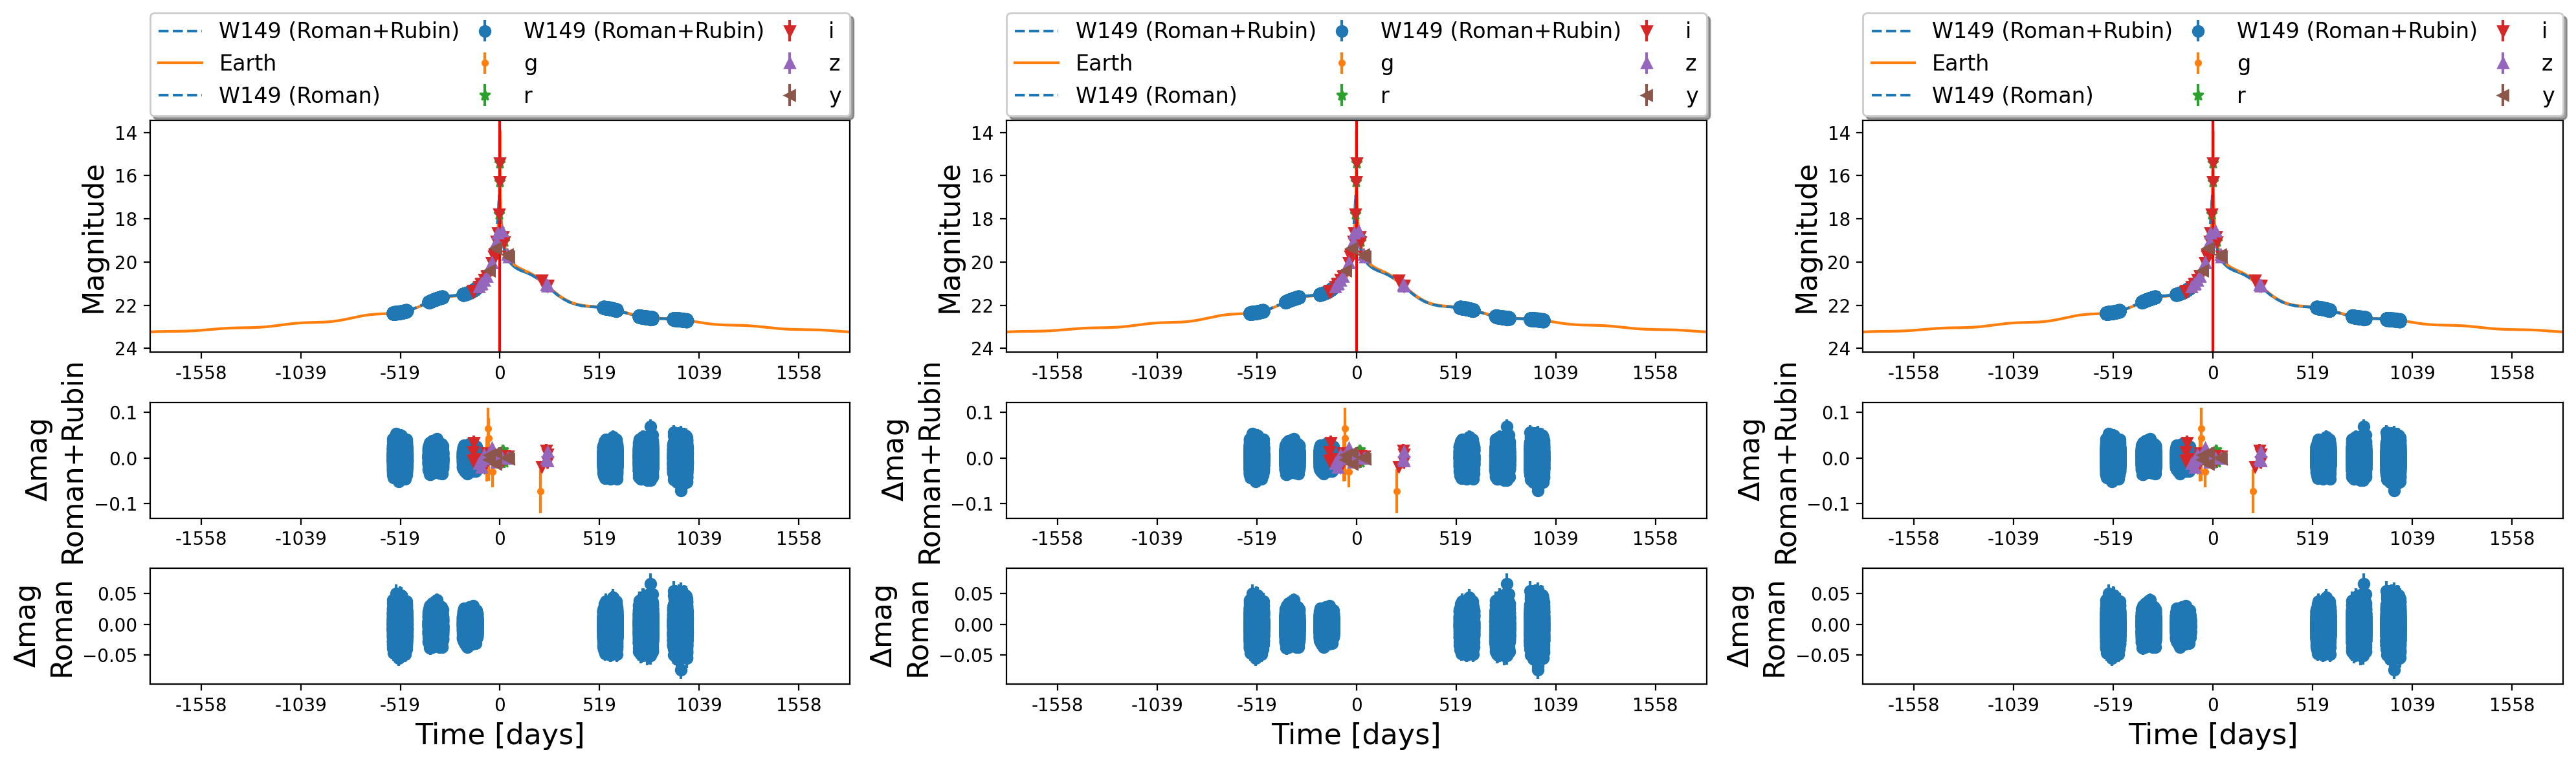

In [89]:
import warnings
from astropy.utils.exceptions import ErfaWarning
warnings.simplefilter('ignore', ErfaWarning)
import contextlib
import io

f = io.StringIO()
with contextlib.redirect_stdout(f):
    fig, axes = plt.subplots(3, 3, figsize=(20, 6),
        gridspec_kw={'height_ratios': [2, 1, 1]},dpi=200)
    
    plot_roman_rubin_plt(axes[0,0], axes[1,0], axes[2,0], source_0, 
                         path_save_0, path_event_0, path_fit_rr_0, path_fit_roman_0, path_ephemerides, 'USBL')
    axes[0,0].invert_yaxis()
    axes[2,0].set_xlabel('Time [days]',fontsize=16)
    axes[2,0].set_ylabel("$\Delta \mathrm{mag}$\nRoman",fontsize=16)
    axes[1,0].set_ylabel("$\Delta \mathrm{mag}$\nRoman+Rubin",fontsize=16)
    axes[0,0].set_ylabel('Magnitude',fontsize=16)
    
    plot_roman_rubin_plt(axes[0,1], axes[1,1], axes[2,1], source_2, 
                         path_save_1, path_event_1, path_fit_rr_1, path_fit_roman_1, path_ephemerides, 'USBL')
    axes[0,1].invert_yaxis()
    axes[2,1].set_xlabel('Time [days]',fontsize=16)
    axes[2,1].set_ylabel("$\Delta \mathrm{mag}$\nRoman",fontsize=16)
    axes[1,1].set_ylabel("$\Delta \mathrm{mag}$\nRoman+Rubin",fontsize=16)
    axes[0,1].set_ylabel('Magnitude',fontsize=16)
    
    plot_roman_rubin_plt(axes[0,2], axes[1,2], axes[2,2], source_2, 
                         path_save_2, path_event_2, path_fit_rr_2, path_fit_roman_2, path_ephemerides, 'USBL')
    axes[0,2].invert_yaxis()
    axes[2,2].set_xlabel('Time [days]',fontsize=16)
    axes[2,2].set_ylabel("$\Delta \mathrm{mag}$\nRoman",fontsize=16)
    axes[1,2].set_ylabel("$\Delta \mathrm{mag}$\nRoman+Rubin",fontsize=16)
    axes[0,2].set_ylabel('Magnitude',fontsize=16)
    
    plt.tight_layout()


In [90]:
# plt.plot([1,1],[2,2])
# plt.xlabel("$\Delta \mathrm{mag}$\nRoman+Rubin")

In [38]:
# from bokeh.io import output_notebook, show
# from bokeh.layouts import gridplot, column
# from bokeh.plotting import figure
# from bokeh.models import Legend
# import contextlib
# import io

# f = io.StringIO()
# with contextlib.redirect_stdout(f):
#     output_notebook()

#     # Generate your three plots
#     plot1 = plot_roman_rubin(source, path_save, path_event, path_fit_rr, path_fit_roman, path_ephemerides, 'USBL')
#     plot2 = plot_roman_rubin(source, path_save, path_event, path_fit_rr, path_fit_roman, path_ephemerides, 'USBL')
#     plot3 = plot_roman_rubin(source, path_save, path_event, path_fit_rr, path_fit_roman, path_ephemerides, 'USBL')

#     # --- Extract legend items from one plot ---
# # Extract main plot from layout (assuming it's the first child in the column)
#     main_plot = plot1.children[0]  # This assumes the first child is the one with the legend
    
#     # Then extract legend items
#     if main_plot.legend:
#         legend_items = main_plot.legend[0].items
#     else:
#         legend_items = []

#     # --- Hide legends in all plots ---
#     for p in [plot1, plot2, plot3]:
#         main = p.children[0]  # Again, assuming first child is the main plot
#         for lg in main.legend:
#             lg.visible = False

#     # --- Create a dummy figure to host the legend ---
#     legend_fig = figure(height=50, width=900, toolbar_location=None,
#                         min_border=0, outline_line_color=None,
#                         x_range=(0, 1), y_range=(0, 1))
    
    # legend = Legend(items=legend_items, location="center", orientation="horizontal")
    # legend_fig.add_layout(legend, 'center')
    # legend_fig.axis.visible = False
    # legend_fig.grid.visible = False

    # # --- Build grid layout ---
    # grid = gridplot([[plot1, plot2, plot3]])
    # final_layout = column(legend_fig, grid)

    # # --- Show final layout ---
    # show(final_layout)


In [22]:
# from bokeh.io import output_notebook, show
# from bokeh.layouts import gridplot, column
# from bokeh.plotting import figure
# from bokeh.models import Legend, LegendItem
# import contextlib
# import io
# f = io.StringIO()
# with contextlib.redirect_stdout(f):
#     output_notebook()
    
#     # --- Extract only the main figure (with legend) from plot_roman_rubin ---
#     def get_main_figure(layout):
#         # Assumes the first child is a figure (adjust this based on your actual layout)
#         for item in layout.children:
#             if isinstance(item, figure):
#                 return item
#             elif hasattr(item, 'children'):
#                 return get_main_figure(item)
#         return None
    
#     # Generate full layouts but only keep the main figure for display
#     layout1 = plot_roman_rubin(source, path_save, path_event, path_fit_rr, path_fit_roman, path_ephemerides, 'USBL')
#     layout2 = plot_roman_rubin(source, path_save, path_event, path_fit_rr, path_fit_roman, path_ephemerides, 'USBL')
#     layout3 = plot_roman_rubin(source, path_save, path_event, path_fit_rr, path_fit_roman, path_ephemerides, 'USBL')
    
#     fig1 = get_main_figure(layout1)
#     fig2 = get_main_figure(layout2)
#     fig3 = get_main_figure(layout3)
    
#     # Extract legend items from the first figure
#     legend_items = []
#     if fig1.legend:
#         for item in fig1.legend[0].items:
#             legend_items.append(LegendItem(label=item.label, renderers=item.renderers))
    
#     # Hide legends in all subplots
#     for fig in [fig1, fig2, fig3]:
#         for lg in fig.legend:
#             lg.visible = False
    
#     # Create a dummy figure to host the unified legend
#     legend_fig = figure(height=50, width=900, toolbar_location=None,
#                         min_border=0, outline_line_color=None,
#                         x_range=(0, 1), y_range=(0, 1))
    
#     legend = Legend(items=legend_items, location="center", orientation="horizontal")
#     legend_fig.add_layout(legend, 'center')
#     legend_fig.axis.visible = False
#     legend_fig.grid.visible = False
    
#     # Create final layout: only show the selected figures in a grid + legend
#     grid = gridplot([[fig1, fig2, fig3]])
#     final_layout = column(legend_fig, grid)
    
#     show(final_layout)


In [21]:
# from bokeh.io import output_notebook, show
# from bokeh.layouts import gridplot, column
# from bokeh.plotting import figure
# from bokeh.models import Legend, LegendItem
# import contextlib
# import io

# f = io.StringIO()
# with contextlib.redirect_stdout(f):
#     output_notebook()
    
#     def get_main_figure(layout):
#         for item in layout.children:
#             if isinstance(item, figure):
#                 return item
#             elif hasattr(item, 'children'):
#                 return get_main_figure(item)
#         return None
    
#     # Generate layouts
#     layout1 = plot_roman_rubin(source, path_save, path_event, path_fit_rr, path_fit_roman, path_ephemerides, 'USBL')
#     layout2 = plot_roman_rubin(source, path_save, path_event, path_fit_rr, path_fit_roman, path_ephemerides, 'USBL')
#     layout3 = plot_roman_rubin(source, path_save, path_event, path_fit_rr, path_fit_roman, path_ephemerides, 'USBL')
    
#     fig1 = get_main_figure(layout1)
#     fig2 = get_main_figure(layout2)
#     fig3 = get_main_figure(layout3)
#     # Remove your legend extraction code and simply do:
#     for fig in [fig1, fig2, fig3]:
#         fig.legend.location = "top_right"
#         fig.legend.click_policy = "hide"  # Makes legend interactive
#         fig.legend.visible = True  # Keep them visible in each plot
#     # Then just show the grid without creating a separate legend
#     show(gridplot([[fig1, fig2, fig3]]))    
    # Create final layout
    # final_layout = column(legend_fig, grid)    
    # show(final_layout)

In [20]:
# from bokeh.io import output_notebook, show
# from bokeh.layouts import gridplot, column
# from bokeh.plotting import figure
# from bokeh.models import Legend, LegendItem
# import contextlib
# import io

# f = io.StringIO()
# with contextlib.redirect_stdout(f):
#     output_notebook()
    
#     def get_main_figure(layout):
#         for item in layout.children:
#             if isinstance(item, figure):
#                 return item
#             elif hasattr(item, 'children'):
#                 return get_main_figure(item)
#         return None
    
#     # Generate layouts
#     layout1 = plot_roman_rubin(source, path_save, path_event, path_fit_rr, path_fit_roman, path_ephemerides, 'USBL')
#     layout2 = plot_roman_rubin(source, path_save, path_event, path_fit_rr, path_fit_roman, path_ephemerides, 'USBL')
#     layout3 = plot_roman_rubin(source, path_save, path_event, path_fit_rr, path_fit_roman, path_ephemerides, 'USBL')
    
#     fig1 = get_main_figure(layout1)
#     fig2 = get_main_figure(layout2)
#     fig3 = get_main_figure(layout3)
    
#     # Hide legends in all subplots
#     for fig in [fig1, fig2, fig3]:
#         fig.legend.visible = False
    
#     # Create a dictionary to store unique legend items
#     legend_items_dict = {}
    
#     # Collect unique legend items from the first figure
#     if fig1.legend:
#         for item in fig1.legend[0].items:
#             if len(item.renderers) > 0 and item.label not in legend_items_dict:
#                 r = item.renderers[0]
#                 # Create new renderers specifically for the legend
#                 if 'line_color' in r.glyph.properties():
#                     legend_renderer = fig1.line([], [], 
#                                               line_color=r.glyph.line_color,
#                                               line_width=r.glyph.line_width if 'line_width' in r.glyph.properties() else 2,
#                                               line_alpha=r.glyph.line_alpha if 'line_alpha' in r.glyph.properties() else 1.0)
#                 elif 'fill_color' in r.glyph.properties():
#                     legend_renderer = fig1.scatter([], [],
#                                                  fill_color=r.glyph.fill_color,
#                                                  size=r.glyph.size if 'size' in r.glyph.properties() else 8,
#                                                  marker=r.glyph.marker if 'marker' in r.glyph.properties() else 'circle',
#                                                  line_color=r.glyph.line_color if 'line_color' in r.glyph.properties() else None)
#                 legend_items_dict[item.label] = legend_renderer
    
#     # Convert the dictionary to legend items
#     legend_items = [LegendItem(label=label, renderers=[renderer]) 
#                    for label, renderer in legend_items_dict.items()]
    
#     # Create a dedicated figure for the legend
#     legend_fig = figure(height=50, width=900, 
#                        toolbar_location=None, 
#                        outline_line_color=None,
#                        x_range=(0, 1), y_range=(0, 1))
#     legend_fig.axis.visible = False
#     legend_fig.grid.visible = False
    
#     # Add the legend to the figure
#     legend = Legend(items=legend_items, 
#                    location="center", 
#                    orientation="horizontal",
#                    spacing=10,
#                    margin=5)
#     legend_fig.add_layout(legend, 'center')
    
#     # Create the grid of plots
#     grid = gridplot([[fig1, fig2, fig3]])
    
#     # Combine everything
#     final_layout = column(legend_fig, grid)
    
#     show(final_layout)

In [19]:
# from bokeh.io import output_notebook, show
# from bokeh.layouts import gridplot, column
# from bokeh.plotting import figure
# from bokeh.models import Legend, LegendItem
# import contextlib
# import io

# f = io.StringIO()
# with contextlib.redirect_stdout(f):
#     output_notebook()
    
#     def get_main_figure(layout):
#         for item in layout.children:
#             if isinstance(item, figure):
#                 return item
#             elif hasattr(item, 'children'):
#                 return get_main_figure(item)
#         return None
    
#     # Generate layouts
#     layout1 = plot_roman_rubin(source, path_save, path_event, path_fit_rr, path_fit_roman, path_ephemerides, 'USBL')
#     layout2 = plot_roman_rubin(source, path_save, path_event, path_fit_rr, path_fit_roman, path_ephemerides, 'USBL')
#     layout3 = plot_roman_rubin(source, path_save, path_event, path_fit_rr, path_fit_roman, path_ephemerides, 'USBL')
    
#     fig1 = get_main_figure(layout1)
#     fig2 = get_main_figure(layout2)
#     fig3 = get_main_figure(layout3)
    
#     # Hide legends in all subplots
#     for fig in [fig1, fig2, fig3]:
#         if fig.legend:
#             fig.legend.visible = False
    
#     # Create a list to store unique legend items
#     legend_items = []
#     seen_labels = set()  # Track labels we've already processed
    
#     # Collect unique legend items from the first figure
#     if fig1.legend:
#         for item in fig1.legend[0].items:
#             # Get the string label value instead of the Value object
#             label = item.label['value'] if isinstance(item.label, dict) else str(item.label)
            
#             if len(item.renderers) > 0 and label not in seen_labels:
#                 seen_labels.add(label)
#                 r = item.renderers[0]
                
#                 # Create new renderers specifically for the legend
#                 if 'line_color' in r.glyph.properties():
#                     legend_renderer = fig1.line([], [], 
#                                               line_color=r.glyph.line_color,
#                                               line_width=r.glyph.line_width if 'line_width' in r.glyph.properties() else 2,
#                                               line_alpha=r.glyph.line_alpha if 'line_alpha' in r.glyph.properties() else 1.0)
#                 elif 'fill_color' in r.glyph.properties():
#                     legend_renderer = fig1.scatter([], [],
#                                                  fill_color=r.glyph.fill_color,
#                                                  size=r.glyph.size if 'size' in r.glyph.properties() else 8,
#                                                  marker=r.glyph.marker if 'marker' in r.glyph.properties() else 'circle',
#                                                  line_color=r.glyph.line_color if 'line_color' in r.glyph.properties() else None)
                
#                 legend_items.append(LegendItem(label=label, renderers=[legend_renderer]))
    
#     # Create a dedicated figure for the legend
#     legend_fig = figure(height=50, width=900, 
#                        toolbar_location=None, 
#                        outline_line_color=None,
#                        x_range=(0, 1), y_range=(0, 1))
#     legend_fig.axis.visible = False
#     legend_fig.grid.visible = False
    
#     # Add the legend to the figure
#     if legend_items:  # Only add if we have items
#         legend = Legend(items=legend_items, 
#                        location="center", 
#                        orientation="horizontal",
#                        spacing=10,
#                        margin=5)
#         legend_fig.add_layout(legend, 'center')
    
#     # Create the grid of plots
#     grid = gridplot([[fig1, fig2, fig3]])
    
#     # Combine everything
#     final_layout = column(legend_fig, grid)
    
#     show(final_layout)

In [18]:
# from bokeh.io import show
# from bokeh.layouts import column
# from bokeh.plotting import figure
# from bokeh.models import Legend, LegendItem
# from bokeh.palettes import Category10_7  # A palette with 7 distinct colors

# # Create your three main figures as before
# layout1 = plot_roman_rubin(source, path_save, path_event, path_fit_rr, path_fit_roman, path_ephemerides, 'USBL')
# layout2 = plot_roman_rubin(source, path_save, path_event, path_fit_rr, path_fit_roman, path_ephemerides, 'USBL')
# layout3 = plot_roman_rubin(source, path_save, path_event, path_fit_rr, path_fit_roman, path_ephemerides, 'USBL')

# fig1 = get_main_figure(layout1)
# fig2 = get_main_figure(layout2)
# fig3 = get_main_figure(layout3)

# # Hide legends in all subplots
# for fig in [fig1, fig2, fig3]:
#     if hasattr(fig, 'legend') and fig.legend:
#         fig.legend.visible = False

# # Create a dedicated figure for the custom legend
# legend_fig = figure(height=100, width=900, 
#                    toolbar_location=None, 
#                    outline_line_color=None,
#                    x_range=(0, 1), y_range=(0, 1))
# legend_fig.axis.visible = False
# legend_fig.grid.visible = False

# # Create 7 dummy renderers with different colors and labels
# labels = ['a', 'b', 'c', 'd', 'e', 'f', 'g']
# colors = Category10_7  # This gives us 7 distinct colors

# legend_items = []
# for i, (label, color) in enumerate(zip(labels, colors)):
#     # Create an invisible scatter plot just for the legend
#     r = legend_fig.scatter([], [], 
#                           fill_color=color,
#                           size=10,
#                           line_color=None,
#                           alpha=0)  # Make points invisible
    
#     # Create the legend item that will actually show
#     legend_items.append(
#         LegendItem(label=label, 
#                   renderers=[r],
#                   index=i)
#     )

# # Add the legend to the figure
# legend = Legend(items=legend_items,
#                location="center",
#                orientation="horizontal",
#                spacing=20,
#                label_text_font_size="10pt",
#                glyph_height=20,
#                glyph_width=20)

# legend_fig.add_layout(legend, 'center')

# # Create the grid of plots
# grid = gridplot([[fig1, fig2, fig3]])
# # Combine everything with the legend on top
# final_layout = column(legend_fig, grid)

# show(final_layout)

In [17]:
# from bokeh.io import show
# from bokeh.layouts import column, gridplot
# from bokeh.plotting import figure
# from bokeh.models import Legend, LegendItem
# from bokeh.palettes import Category10_7

# # Generate your plots as before
# layout1 = plot_roman_rubin(source, path_save, path_event, path_fit_rr, path_fit_roman, path_ephemerides, 'USBL')
# layout2 = plot_roman_rubin(source, path_save, path_event, path_fit_rr, path_fit_roman, path_ephemerides, 'USBL') 
# layout3 = plot_roman_rubin(source, path_save, path_event, path_fit_rr, path_fit_roman, path_ephemerides, 'USBL')

# fig1 = get_main_figure(layout1)
# fig2 = get_main_figure(layout2) 
# fig3 = get_main_figure(layout3)

# # Hide original legends
# for fig in [fig1, fig2, fig3]:
#     if hasattr(fig, 'legend') and fig.legend:
#         fig.legend.visible = False

# # Create dummy figure for legend
# legend_fig = figure(height=150, width=900,
#                    toolbar_location=None,
#                    outline_line_color=None,
#                    x_range=(0,1), y_range=(0,1))
# legend_fig.axis.visible = False
# legend_fig.grid.visible = False

# # Create actual data points that will show in legend
# labels = ['a', 'b', 'c', 'd', 'e', 'f', 'g']
# colors = Category10_7

# # Plot real points (not just legend markers)
# for i, (label, color) in enumerate(zip(labels, colors)):
#     # Position points evenly across the legend space
#     x = 0.1 + i*0.12
#     legend_fig.scatter([x], [0.5], 
#                      size=12,
#                      fill_color=color,
#                      line_color='black',
#                      legend_label=label)

# # Style the legend
# legend_fig.legend.location = "center"
# legend_fig.legend.orientation = "horizontal"
# legend_fig.legend.label_text_font_size = "12pt"
# legend_fig.legend.glyph_height = 20
# legend_fig.legend.glyph_width = 20
# legend_fig.legend.spacing = 15

# # Create grid of your three plots
# grid = gridplot([[fig1, fig2, fig3]])

# # Combine legend and plots
# final_layout = column(legend_fig, grid)

# show(final_layout)

In [31]:
# from bokeh.io import output_notebook
# from bokeh.layouts import gridplot, row, column
# import contextlib
# import io

# from bokeh.models import Legend

# # Combine all legends (optional if needed)
# f = io.StringIO()
# with contextlib.redirect_stdout(f):
#     output_notebook()
#     plot1 = plot_roman_rubin(source,path_save,path_event, path_fit_rr, path_fit_roman, path_ephemerides,'USBL')
#     plot2 = plot_roman_rubin(source,path_save,path_event, path_fit_rr, path_fit_roman, path_ephemerides,'USBL')
#     plot3 = plot_roman_rubin(source,path_save,path_event, path_fit_rr, path_fit_roman, path_ephemerides,'USBL')

#     for p in [plot1, plot2, plot3]:
#         p.legend.visible = False
#     legend_fig = figure(height=50, width=900, toolbar_location=None, min_border=0,
#                         outline_line_color=None, x_range=(0, 1), y_range=(0, 1))
    
#     legend = Legend(items=legend_items, location="center", orientation="horizontal")
#     legend_fig.add_layout(legend, 'center')
#     legend_fig.axis.visible = False
#     legend_fig.grid.visible = False
    
#     # --- Layout: unified legend on top ---
#     grid = gridplot([[plot1, plot2, plot3]])
#     final_layout = column(legend_fig, grid)
    
#     # Show
#     show(final_layout)


In [32]:
# from bokeh.plotting import figure, show
# from bokeh.models import Legend
# from bokeh.layouts import gridplot, column
# from bokeh.io import output_notebook

# output_notebook()  # Only needed in Jupyter notebooks

# # --- Create 3 plots with the same legend labels ---
# colors = ['blue', 'red']
# labels = ['Model A', 'Model B']

# # Generate some dummy data
# x = [1, 2, 3, 4, 5]
# y1 = [1, 4, 9, 16, 25]
# y2 = [25, 16, 9, 4, 1]

# def create_plot():
#     p = figure(width=300, height=300)
#     r1 = p.line(x, y1, color=colors[0], line_width=2, legend_label=labels[0])
#     r2 = p.line(x, y2, color=colors[1], line_width=2, legend_label=labels[1])
#     return p, r1, r2

# # Create 3 plots with same content for demonstration
# plot1, r1_1, r1_2 = create_plot()
# plot2, r2_1, r2_2 = create_plot()
# plot3, r3_1, r3_2 = create_plot()

# # Extract legend items from plot1
# legend_items = plot1.legend[0].items

# # Hide legends in all plots
# for p in [plot1, plot2, plot3]:
#     p.legend.visible = False

# # --- Create a dummy plot to host the unified legend ---
# legend_fig = figure(height=50, width=900, toolbar_location=None, min_border=0,
#                     outline_line_color=None, x_range=(0, 1), y_range=(0, 1))

# legend = Legend(items=legend_items, location="center", orientation="horizontal")
# legend_fig.add_layout(legend, 'center')
# legend_fig.axis.visible = False
# legend_fig.grid.visible = False

# # --- Layout: unified legend on top ---
# grid = gridplot([[plot1, plot2, plot3]])
# final_layout = column(legend_fig, grid)

# # Show
# show(final_layout)


In [12]:
# plot_n_save(source,path_save,path_event, path_fit_rr, path_fit_roman, path_ephemerides,'USBL')